# 01 — Regularización (Ridge, Lasso, ElasticNet)

**Módulo 2 · Algoritmos avanzados de ML (+ MLflow)**

En este notebook estudiamos la **regularización**: una familia de técnicas que
limitan la complejidad de un modelo para mejorar su **generalización**. Vemos la
intuición y las fórmulas clave de **Ridge (L2)**, **Lasso (L1)** y
**ElasticNet**, entrenamos las tres sobre el dataset **California housing**,
comparamos sus coeficientes y su error en validación cruzada, y registramos cada
experimento con **MLflow**, guardando el mejor modelo en el **Model Registry**.


## 1. ¿Por qué regularizar? Sobreajuste y el compromiso sesgo–varianza

**Idea intuitiva:** un modelo demasiado flexible memoriza el ruido de los datos
de entrenamiento y luego falla con datos nuevos (sobreajuste); uno demasiado
simple no capta ni la señal (subajuste). La regularización busca el punto medio.

Formalmente, para el error cuadrático el error de generalización se descompone:

$$
\mathbb{E}\big[(y - \hat f(x))^2\big]
= \underbrace{\text{sesgo}^2}_{\text{modelo muy simple}}
+ \underbrace{\text{varianza}}_{\text{modelo muy flexible}}
+ \underbrace{\sigma^2}_{\text{ruido irreducible}}.
$$

La **regularización** añade una *penalización* sobre el tamaño de los parámetros:

$$
\min_{\beta}\; \underbrace{L(\beta)}_{\text{ajuste a los datos}} \; + \; \lambda \, R(\beta),
$$

cambiando un poco más de sesgo por una gran reducción de varianza. El
hiperparámetro $\lambda$ (llamado `alpha` en scikit-learn) controla la fuerza.


In [1]:

import os, sys, warnings
warnings.filterwarnings("ignore")

# Hacemos importable utils/ tanto si el notebook corre desde notebooks/ como
# desde la raíz del repositorio.
_here = os.getcwd()
for cand in (os.path.join(_here, "..", "utils"), os.path.join(_here, "utils"),
             os.path.join(_here, "..", "..", "module2-advanced-ml", "utils")):
    cand = os.path.abspath(cand)
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow_helpers import setup_mlflow, log_and_register, register_best_run, registry_available

np.random.seed(42)
print("Versión de MLflow:", mlflow.__version__)


Versión de MLflow: 3.14.0


In [2]:

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target
feature_names = list(X.columns)
print("Dimensiones:", X.shape, "| objetivo = valor mediano de la vivienda ($100k)")
X.head()


Dimensiones: (20640, 8) | objetivo = valor mediano de la vivienda ($100k)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:

# La regularización penaliza la MAGNITUD de los coeficientes, así que las
# variables deben estar en la misma escala. Estandarizamos (media 0, desv. 1).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train_s.shape, "Test:", X_test_s.shape)


Train: (16512, 8) Test: (4128, 8)


## 2. Tracking de experimentos y Model Registry: por qué importan

**El tracking de experimentos** registra *cada* ejecución: sus parámetros (p. ej.
`alpha`), sus métricas (p. ej. RMSE en test), la versión del código y los
artefactos (el modelo entrenado, gráficas). Sin él, comparar decenas de modelos
es adivinar y los resultados no son reproducibles.

**El Model Registry** es un catálogo versionado de *modelos* (no de ejecuciones).
Permite promover una versión concreta por etapas (Staging → Production), adjuntar
metadatos y servir una única fuente de verdad a los sistemas aguas abajo.

**MLflow** nos da ambas cosas. Lo configuramos una vez con nuestro helper, que
apunta al tracking server (`http://localhost:5000`) o cae a un store local.


In [4]:

setup_mlflow("module2-01-regularization", backend="dagshub")


Accessing as abdala9512

Initialized MLflow to track repo "abdala9512/dsrp-machine-learning-engineering-20262"

Repository abdala9512/dsrp-machine-learning-engineering-20262 initialized!

[mlflow_helpers] Backend      : dagshub
[mlflow_helpers] Tracking URI : https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow
[mlflow_helpers] Experiment   : module2-01-regularization


'https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow'

## 3. Regresión Ridge (L2)

**Intuición:** Ridge encoge todos los coeficientes hacia cero (sin anularlos),
lo que estabiliza el modelo cuando hay variables muy correlacionadas.

Resuelve:

$$
\hat\beta_{\text{ridge}} = \arg\min_\beta \; \|y - X\beta\|_2^2 + \alpha\,\|\beta\|_2^2,
\qquad \|\beta\|_2^2 = \sum_j \beta_j^2 .
$$

Tiene **solución cerrada** (siempre invertible para $\alpha>0$):

$$
\hat\beta_{\text{ridge}} = (X^\top X + \alpha I)^{-1} X^\top y .
$$

El término $\alpha I$ *encoge* los coeficientes y estabiliza la inversa cuando
las variables son colineales. Visualicemos el **camino de encogimiento** según
crece $\alpha$.


In [9]:
alphas = np.logspace(-2, 4, 10)

alphas

array([1.00000000e-02, 4.64158883e-02, 2.15443469e-01, 1.00000000e+00,
       4.64158883e+00, 2.15443469e+01, 1.00000000e+02, 4.64158883e+02,
       2.15443469e+03, 1.00000000e+04])

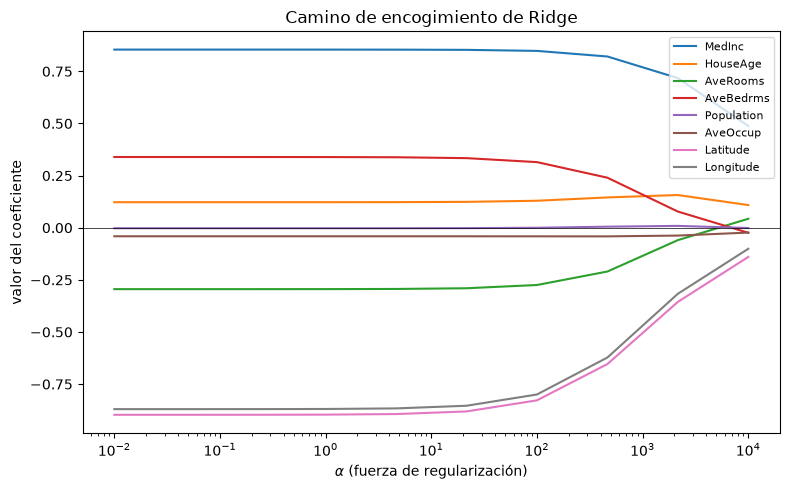

In [10]:
from sklearn.linear_model import Ridge

alphas = np.logspace(-2, 4, 10)
coefs = []
for a in alphas:
    m = Ridge(alpha=a).fit(X_train_s, y_train)
    coefs.append(m.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(8, 5))
for j, name in enumerate(feature_names):
    plt.plot(alphas, coefs[:, j], label=name)
plt.xscale("log")
plt.xlabel(r"$\alpha$ (fuerza de regularización)")
plt.ylabel("valor del coeficiente")
plt.title("Camino de encogimiento de Ridge")
plt.legend(fontsize=8); plt.axhline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()


## 4. Regresión Lasso (L1): esparsidad y selección de variables

**Intuición:** Lasso no sólo encoge, sino que lleva algunos coeficientes a
**exactamente cero**, eligiendo automáticamente qué variables conservar.

Reemplaza la penalización L2 por la **norma L1**:

$$
\hat\beta_{\text{lasso}} = \arg\min_\beta \; \|y - X\beta\|_2^2 + \alpha\,\|\beta\|_1,
\qquad \|\beta\|_1 = \sum_j |\beta_j| .
$$

No tiene forma cerrada (la L1 no es diferenciable en 0); se resuelve por
descenso por coordenadas.

### Geometría: por qué L1 → esparsidad y L2 → encogimiento
Las regiones de restricción son $\|\beta\|_1 \le t$ (un rombo) frente a
$\|\beta\|_2 \le t$ (un círculo). Los contornos elípticos del error cuadrático
tocan primero las **esquinas** del rombo —que caen sobre los ejes (algún
$\beta_j = 0$)— mientras que tocan el círculo suave en un punto cualquiera (sin
ceros exactos).


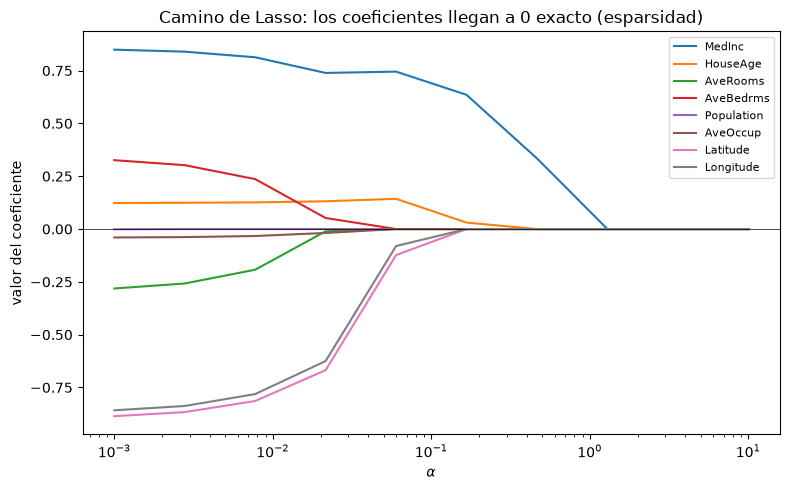

In [11]:

from sklearn.linear_model import Lasso

alphas_l = np.logspace(-3, 1, 10)
coefs_l = []
for a in alphas_l:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    coefs_l.append(m.coef_)
coefs_l = np.array(coefs_l)

plt.figure(figsize=(8, 5))
for j, name in enumerate(feature_names):
    plt.plot(alphas_l, coefs_l[:, j], label=name)
plt.xscale("log")
plt.xlabel(r"$\alpha$"); plt.ylabel("valor del coeficiente")
plt.title("Camino de Lasso: los coeficientes llegan a 0 exacto (esparsidad)")
plt.legend(fontsize=8); plt.axhline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()


## 5. ElasticNet: la penalización combinada

**Intuición:** ElasticNet mezcla L1 y L2, así que conserva la esparsidad de Lasso
pero reparte mejor el peso entre **grupos de variables correlacionadas** (Lasso
tiende a quedarse con una arbitrariamente).

$$
\hat\beta = \arg\min_\beta \; \frac{1}{2n}\|y - X\beta\|_2^2
+ \alpha\Big( \rho\,\|\beta\|_1 + \tfrac{1-\rho}{2}\,\|\beta\|_2^2 \Big),
$$

donde `l1_ratio` $= \rho \in [0,1]$ interpola entre Ridge ($\rho=0$) y Lasso
($\rho=1$).


## 6. Entrenar las tres, comparar y registrar en MLflow

Comparamos Ridge, Lasso y ElasticNet por RMSE en validación cruzada de 5 folds
sobre el set de entrenamiento, y reportamos RMSE / $R^2$ en test. Cada uno se
registra como una ejecución de MLflow; el mejor (menor RMSE en CV) se registra.


In [12]:

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

def rmse(y_true, y_pred):
    # Funciona en distintas versiones de sklearn (squared= se quitó en 1.8)
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate(model, name, params):
    cv_rmse = -cross_val_score(model, X_train_s, y_train, cv=5,
                               scoring="neg_root_mean_squared_error").mean()
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    test_rmse = rmse(y_test, pred)
    test_r2 = r2_score(y_test, pred)
    n_nonzero = int(np.sum(np.abs(model.coef_) > 1e-8))
    metrics = {"cv_rmse": cv_rmse, "test_rmse": test_rmse,
               "test_r2": test_r2, "n_nonzero_coef": n_nonzero}
    run_id = log_and_register(run_name=name, params=params, metrics=metrics,
                              model=model, flavor="sklearn",
                              tags={"family": "linear", "algo": name})
    print(f"{name:12s} | CV RMSE {cv_rmse:.4f} | test RMSE {test_rmse:.4f} | "
          f"R2 {test_r2:.4f} | no nulos {n_nonzero}")
    return metrics, model

results = {}
results["Ridge"], ridge = evaluate(Ridge(alpha=1.0), "Ridge", {"alpha": 1.0})
results["Lasso"], lasso = evaluate(Lasso(alpha=0.01, max_iter=10000), "Lasso", {"alpha": 0.01})
results["ElasticNet"], enet = evaluate(
    ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "ElasticNet", {"alpha": 0.01, "l1_ratio": 0.5})


2026/07/15 20:41:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Ridge at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/0/runs/d7234f6be27a4d87860b2baac8997fcc
🧪 View experiment at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/0
Ridge        | CV RMSE 0.7205 | test RMSE 0.7456 | R2 0.5758 | no nulos 8


2026/07/15 20:41:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Lasso at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/0/runs/2e8614b986984c8b96790141723d494e
🧪 View experiment at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/0
Lasso        | CV RMSE 0.7241 | test RMSE 0.7404 | R2 0.5816 | no nulos 7


2026/07/15 20:42:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run ElasticNet at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/0/runs/60d1ac41a7c2491e8e72308415dd4bac
🧪 View experiment at: https://dagshub.com/abdala9512/dsrp-machine-learning-engineering-20262.mlflow/#/experiments/0
ElasticNet   | CV RMSE 0.7226 | test RMSE 0.7416 | R2 0.5803 | no nulos 7


In [13]:

# Comparación de coeficientes
comp = pd.DataFrame({"feature": feature_names,
                     "Ridge": ridge.coef_, "Lasso": lasso.coef_,
                     "ElasticNet": enet.coef_})
comp


,feature,Ridge,Lasso,ElasticNet
0,MedInc,0.854327,0.800957,0.823963
1,HouseAge,0.122624,0.127087,0.130005
2,AveRooms,-0.294210,-0.162759,-0.216074
3,AveBedrms,0.339008,0.206207,0.256299
4,Population,-0.002282,-0.000000,-0.000000
5,AveOccup,-0.040833,-0.030602,-0.035948
6,Latitude,-0.896168,-0.790113,-0.788420
7,Longitude,-0.869071,-0.755674,-0.757036


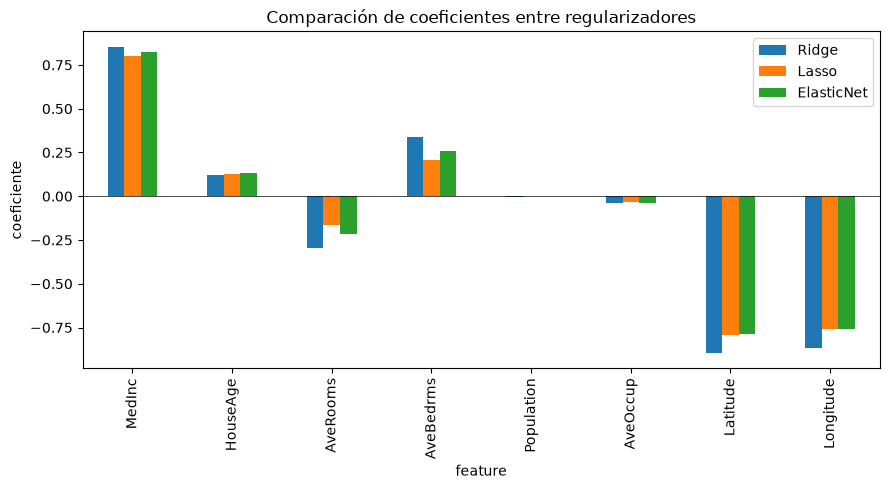

In [14]:

comp.set_index("feature").plot.bar(figsize=(9,5))
plt.title("Comparación de coeficientes entre regularizadores")
plt.ylabel("coeficiente"); plt.axhline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()


In [16]:

# Registramos el mejor modelo (menor RMSE en CV) en el Model Registry
register_best_run("module2-01-regularization", metric="cv_rmse",
                  registered_model_name="california-housing-regularized-NEW",
                  mode="min")


Successfully registered model 'california-housing-regularized-NEW'.
2026/07/15 20:52:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: california-housing-regularized-NEW, version 1
Created version '1' of model 'california-housing-regularized-NEW'.


[mlflow_helpers] Best run d7234f6be27a4d87860b2baac8997fcc (cv_rmse=0.7205) registered as 'california-housing-regularized-NEW' v1


'1'

## 7. Resumen

| Método | Penalización | Efecto | ¿Forma cerrada? |
|---|---|---|---|
| Ridge | $\alpha\|\beta\|_2^2$ | encoge todos, ninguno cero | sí |
| Lasso | $\alpha\|\beta\|_1$ | esparso, selección de variables | no (desc. por coordenadas) |
| ElasticNet | mezcla vía `l1_ratio` | esparso + maneja correlación | no |

La regularización es tu primera línea de defensa contra el sobreajuste. Ajusta
`alpha` (y `l1_ratio`) por validación cruzada, y deja que MLflow guarde la
evidencia. Abre la UI en **http://localhost:5000** para inspeccionar runs y el
registry.
